Data Analytics (DA) **

**Module-End -5**

**Module End  Assignment: Python For Data Analysis**

**“Social Media Engagement Analytics”**

Dataset provided : social_media_engagement_5000.csv

❖ Task 1 — Data Import & Setup

○ Import CSV using Pandas ○ Check/convert data types ○ Convert date columns to datetime ○ Use NumPy arrays for basic array operations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#downloading the csv file
from google.colab import files

uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [ ]:
df = pd.read_csv("social_media_engagement_5000.csv")

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
#number of rows and columns

df.shape

(5000, 19)

In [ ]:
#columns detail
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
#data types
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
# complete data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
#handling the missing values in age column and converting datatype
df['age'] = df['age'].fillna(df['age'].median()).astype(int)

❖	Task 2 — Data Cleaning
●	 Cleaning Missing Data

■	Detect missing values (isnull(), isna())
■	Handle using: dropna(), fillna(), median/mode, forward/backward-fill


In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
# filling the missing values in age column
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
# filling "unknown" in gender column
df['gender'] = df['gender'].fillna('Unknown')

In [ ]:
df['likes'] = df['likes'].fillna(df['likes'].mode()[0])
df['comments'] = df['comments'].fillna(df['comments'].mode()[0])
df['shares'] = df['shares'].fillna(df['shares'].mode()[0])

In [ ]:
# removing missing rows
df_drop = df.dropna()
df_drop.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


●	Duplicate Handling
■	Identify & remove duplicates


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df[df.duplicated()]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

●	Data Formatting

■	Fix incorrect data types
■	Standardize categories (e.g., gender labels)
■	Correct unrealistic values in likes, comments, shares


In [ ]:
# Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'])


In [ ]:
# Standardize gender
df['gender'] = df['gender'].str.lower().str.strip()

df['gender'] = df['gender'].replace({
    'm': 'male',
    'f': 'female'
})

In [ ]:
# Identify unrealistic negative values
print("Negative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

Negative likes: 0
Negative comments: 0
Negative shares: 0


In [ ]:
# Replace negative values with NaN
df.loc[df['likes'] < 0, 'likes'] = np.nan
df.loc[df['comments'] < 0, 'comments'] = np.nan
df.loc[df['shares'] < 0, 'shares'] = np.nan

In [ ]:
# Fill with mode
for col in ['likes', 'comments', 'shares']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

●	 **Feature Cleaning**

■	Extract hashtag count
■	Clean sentiment labels


In [ ]:
#how the hashtags are actually stored
df['hashtags'].head(10)

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel
5,#fitness
6,#music
7,#travel #music #fitness
8,#music #fun #fitness
9,#lifestyle #love


In [ ]:
df['hashtag_count'] = df['hashtags'].fillna('').str.count('#')

In [ ]:
# Clean sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()

In [ ]:
# Fill missing sentiment values
df['sentiment'] = df['sentiment'].fillna('unknown')


In [ ]:
# Check the results
print(df[['hashtags', 'hashtag_count']].head())
print(df['sentiment'].value_counts())

                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1
sentiment
positive    2363
neutral     1527
negative     960
unknown      150
Name: count, dtype: int64


❖	**Task 3 — Data Exploration using Pandas**



●	View dataset structure using head(), tail(), shape, and columns

In [ ]:
# View first 5 rows
print("First 5 rows:")
display(df.head())

# View last 5 rows
print("Last 5 rows:")
display(df.tail())

# View dataset shape
print("Dataset shape:", df.shape)

# View column names
print("Column names:")
print(df.columns.tolist())

First 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


Last 5 rows:


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,female,USA,273595,text,travel,13487.0,2934.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


Dataset shape: (5000, 20)
Column names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


●	Check data types and info with info() and dtypes

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


●	Generate summary statistics using describe().

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,9998.412400,1545.149800,976.690600,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,447.750000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,9776.000000,1540.000000,981.500000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2323.000000,1483.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5735.658626,890.548991,589.603387,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


●	Analyze categorical distributions using value_counts(), unique(), and nunique().

In [ ]:
print("Unique values:")
print(df['gender'].unique())

print("\nNumber of unique values:")
print(df['gender'].nunique())

print("\nCategory counts:")
print(df['gender'].value_counts())

Unique values:
['female' 'male' 'other' 'unknown']

Number of unique values:
4

Category counts:
gender
male       1699
other      1581
female     1570
unknown     150
Name: count, dtype: int64


In [ ]:
categorical_columns = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'
]

for col in categorical_columns:
    print("\n---", col, "---")
    print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())
    print("Value counts:")
    print(df[col].value_counts())


--- gender ---
Unique values: ['female' 'male' 'other' 'unknown']
Number of unique values: 4
Value counts:
gender
male       1699
other      1581
female     1570
unknown     150
Name: count, dtype: int64

--- country ---
Unique values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Number of unique values: 10
Value counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

--- post_type ---
Unique values: ['image' 'reel' 'text' 'video']
Number of unique values: 4
Value counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

--- post_category ---
Unique values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Number of unique values: 8
Value counts:
post_category
fitness      675
tech         665
music        635
education  

●	Create a correlation matrix for numeric fields.

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.024422,-0.026628,0.015279,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.037855,-0.007094,0.012806,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.013231,-0.010723,0.004168,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.024422,-0.037855,0.013231,1.000000,-0.020030,0.000155,0.006624,0.006096,-0.023470,-0.014614,0.094814,-0.002675
comments,-0.026628,-0.007094,-0.010723,-0.020030,1.000000,0.003638,-0.014429,-0.008255,-0.013778,-0.013550,-0.001315,-0.014960
shares,0.015279,0.012806,0.004168,0.000155,0.003638,1.000000,0.015353,0.004898,-0.006643,0.012312,0.021465,0.019443
watch_time_sec,-0.016847,0.005542,0.018374,0.006624,-0.014429,0.015353,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.006096,-0.008255,0.004898,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.023470,-0.013778,-0.006643,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.014614,-0.013550,0.012312,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


●	Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

In [ ]:
# Average likes by post type
avg_likes_by_post_type = df.groupby('post_type')['likes'].mean()
print(avg_likes_by_post_type)

# Total impressions by country
impressions_by_country = df.groupby('country')['impression_count'].sum()
print(impressions_by_country)

post_type
image    10011.983160
reel      9910.851910
text      9986.766265
video    10088.140408
Name: likes, dtype: float64
country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64


❖	**Task 4 — Data Wrangling **

●	Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag_count.

In [ ]:
import numpy as np

# Engagement score
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]

# Hashtag count
df["hashtag_count"] = df["hashtags"].fillna("").apply(
    lambda x: len(x.split())
)

# Log-transformed metrics
df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])

# View the result
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,log_likes,log_comments,log_shares
0,25795,43,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0,8.855378,5.872118,7.054450
1,10860,33,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,False,mobile,negative,#fitness,0.201493,1,16163.0,9.371694,7.865955,7.499977
2,86820,32,female,UK,109864,text,food,4862.0,344.0,955.0,...,False,tablet,positive,#foodie,0.137345,1,6161.0,8.489411,5.843544,6.862758
3,64886,51,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0,8.585039,6.988413,6.956545
4,16265,34,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,False,mobile,negative,#travel,2.777372,1,16717.0,9.448018,7.914252,7.170888


●	Perform groupby summaries by post_type, country, and sentiment.

In [ ]:
# Summary by post type
df.groupby("post_type")[["likes", "comments", "shares", "engagement_score"]].mean()

# Summary by country
df.groupby("country")[["likes", "comments", "shares", "engagement_score"]].mean()

# Summary by sentiment
df.groupby("sentiment")[["likes", "comments", "shares", "engagement_score"]].mean()

,likes,comments,shares,engagement_score
sentiment,,,,
negative,10094.987500,1552.019792,985.457292,12632.464583
neutral,9818.899804,1566.987557,973.670596,12359.557957
positive,10046.641557,1531.051629,970.441811,12548.134998
unknown,10448.000000,1500.966667,1049.766667,12998.733333


❖	Task 5 — Statistical Analysis

Compute descriptive stats for likes, comments, shares, watch_time, engagement_rate, followers:


In [ ]:
columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

numeric_data = df[columns]

print("Mean:")
print(numeric_data.mean())

print("\nMedian:")
print(numeric_data.median())

print("\nMode:")
print(numeric_data.mode().iloc[0])

print("\nStandard Deviation:")
print(numeric_data.std())

print("\nVariance:")
print(numeric_data.var())

print("\nPercentiles:")
print(numeric_data.quantile([0.25, 0.50, 0.75]))

print("\nSkewness:")
print(numeric_data.skew())

print("\nKurtosis:")
print(numeric_data.kurtosis())

Mean:
likes                9998.412400
comments             1545.149800
shares                976.690600
watch_time_sec       4014.503200
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

Median:
likes                9776.000000
comments             1540.000000
shares                981.500000
watch_time_sec       4034.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64

Mode:
likes                6486.000000
comments             2934.000000
shares                138.000000
watch_time_sec        916.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64

Standard Deviation:
likes                5735.658626
comments              890.548991
shares                589.603387
watch_time_sec       2308.096459
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

Variance:
likes              3.289778e+07
comments           7.930775e+05
shares             3.

❖	Task 6 — Data Visualization (Min. 8 Plots Required)

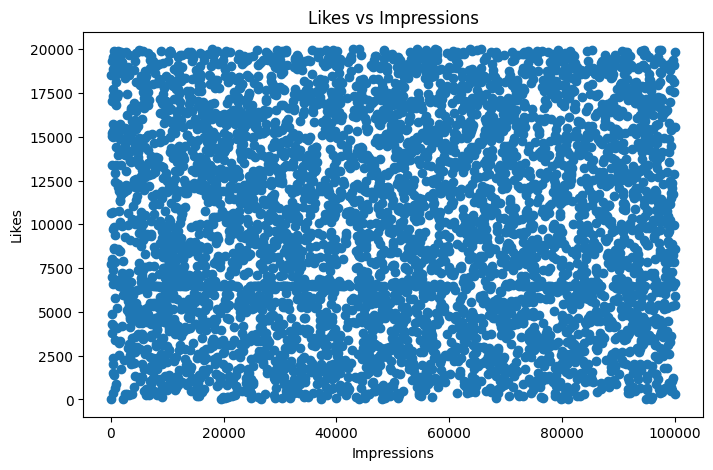

In [ ]:
#scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["impression_count"], df["likes"])

plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.title("Likes vs Impressions")

plt.show()

In [ ]:
#line plot - daily engagement trend
daily_engagement = df.groupby(
    df["posted_at"].dt.date
)["engagement_rate"].mean()

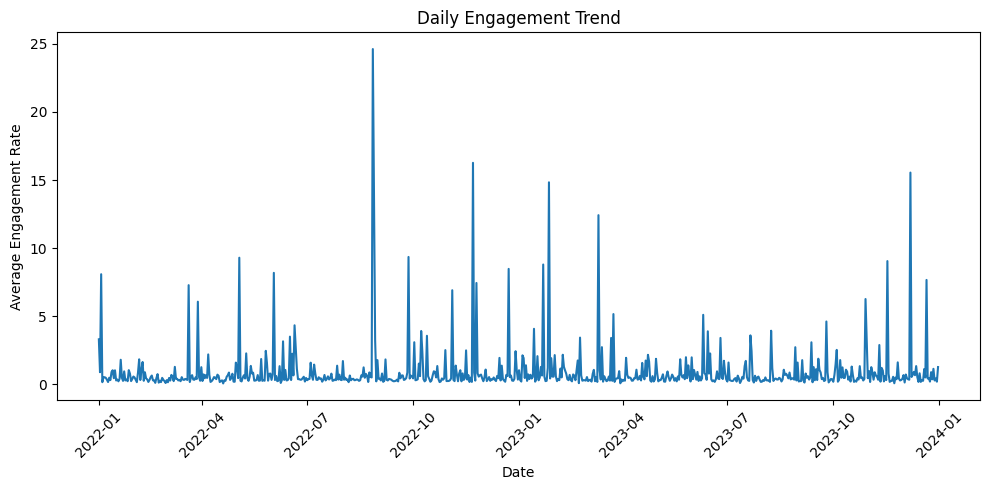

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(daily_engagement.index, daily_engagement.values)

plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.title("Daily Engagement Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

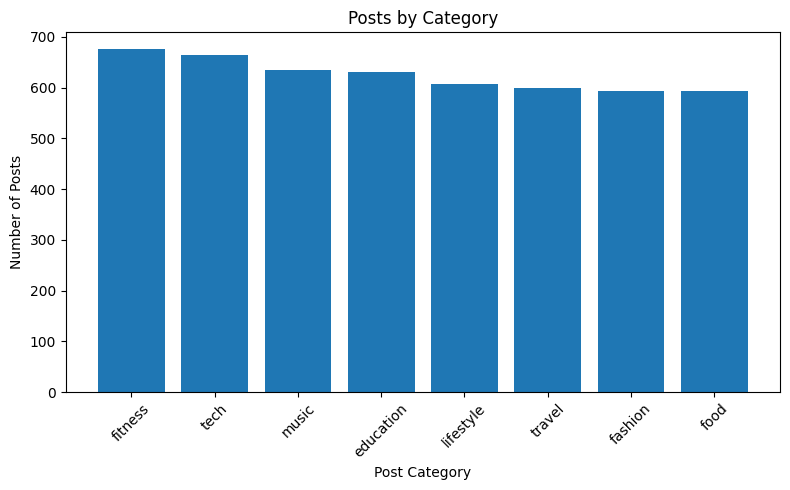

In [ ]:
#Bar chart - post by category
category_counts = df["post_category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(category_counts.index, category_counts.values)

plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.title("Posts by Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

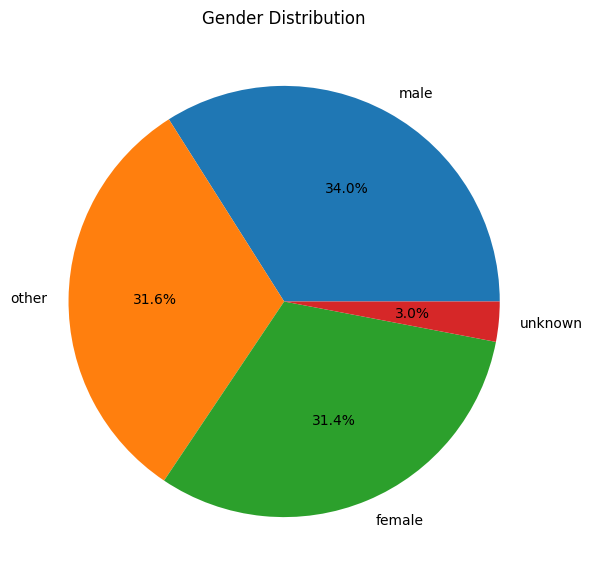

In [ ]:
#pie chart - Gender distribution
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

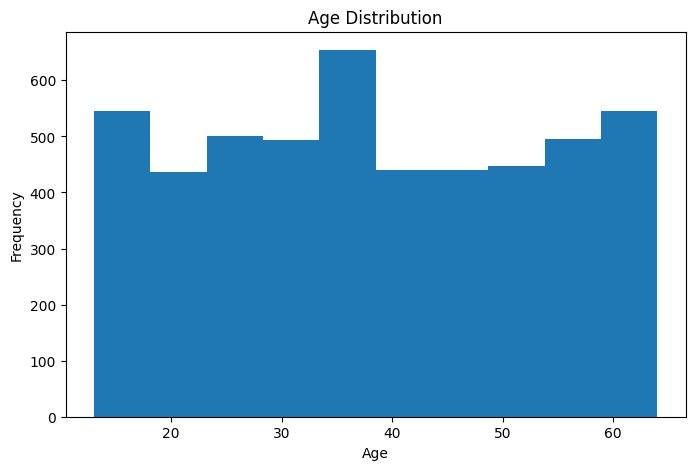

In [ ]:
#histogram
plt.figure(figsize=(8, 5))

plt.hist(df["age"].dropna(), bins=10)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

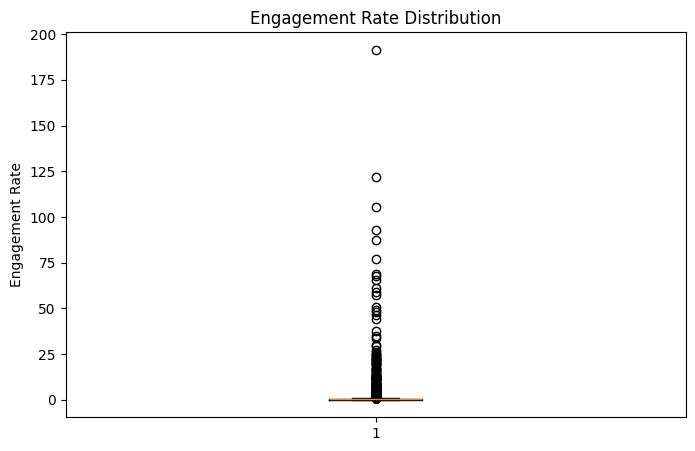

In [ ]:
#box plot - Engagement rate
plt.figure(figsize=(8, 5))

plt.boxplot(df["engagement_rate"].dropna())

plt.ylabel("Engagement Rate")
plt.title("Engagement Rate Distribution")

plt.show()

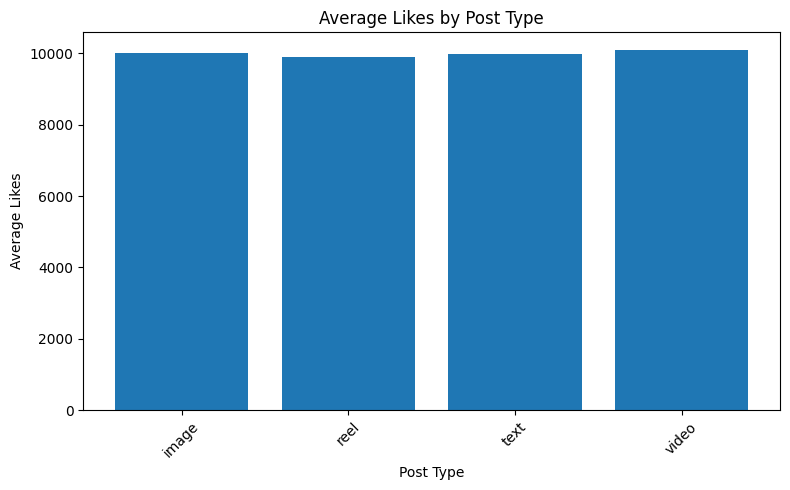

In [ ]:
#Bar Chart — Average Likes by Post Type
avg_likes = df.groupby("post_type")["likes"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_likes.index, avg_likes.values)

plt.xlabel("Post Type")
plt.ylabel("Average Likes")
plt.title("Average Likes by Post Type")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

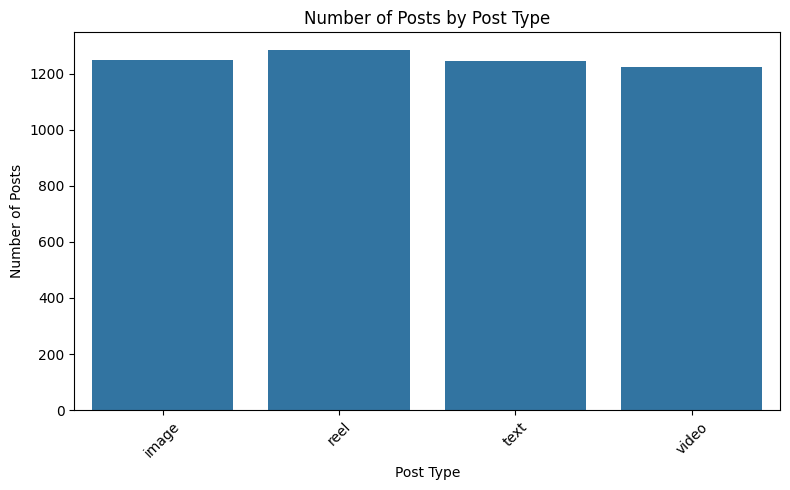

In [ ]:
#Count Plot — Post Type
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="post_type")

plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.title("Number of Posts by Post Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

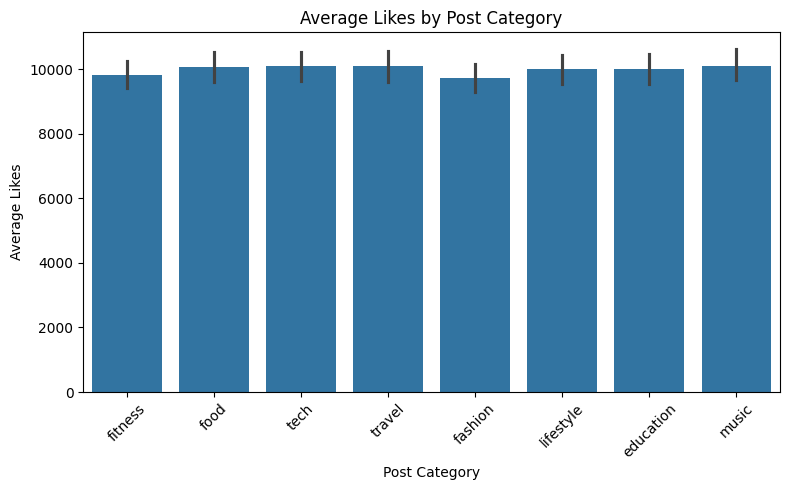

In [ ]:
#Bar Plot — Average Likes by Category
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean"
)

plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.title("Average Likes by Post Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

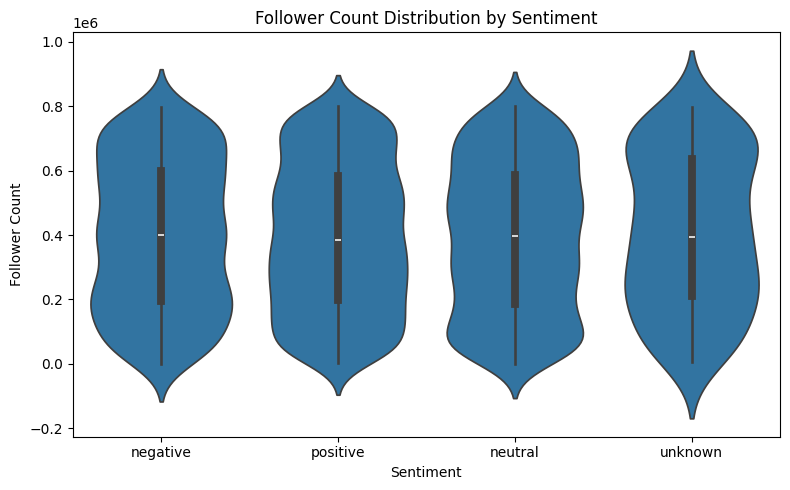

In [ ]:
#Violin Plot — Followers vs Sentiment
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.title("Follower Count Distribution by Sentiment")

plt.tight_layout()
plt.show()

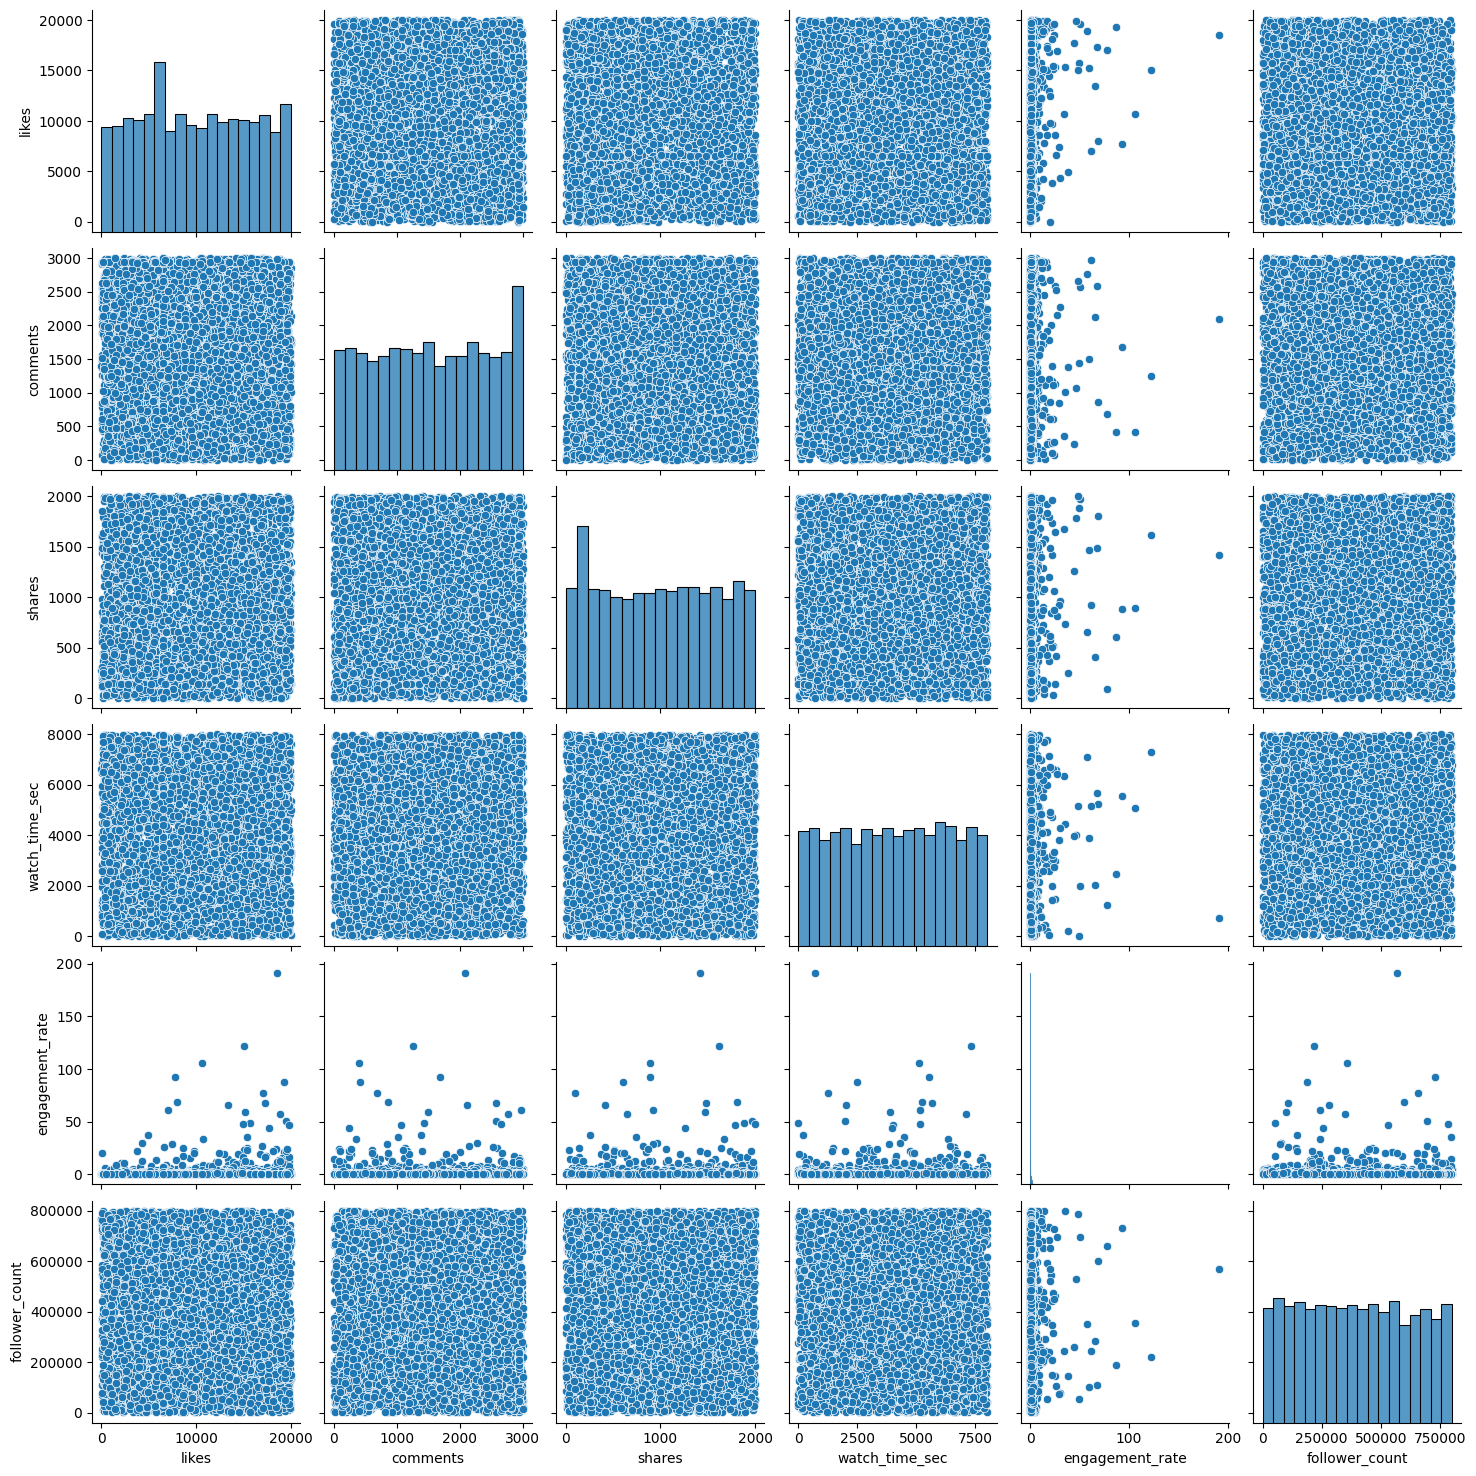

In [ ]:
#Pair Plot — Numeric Features
numeric_features = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

sns.pairplot(df[numeric_features].dropna())

plt.show()

In [ ]:
#Heatmap — Correlation Matrix
correlation = df[numeric_features].corr()

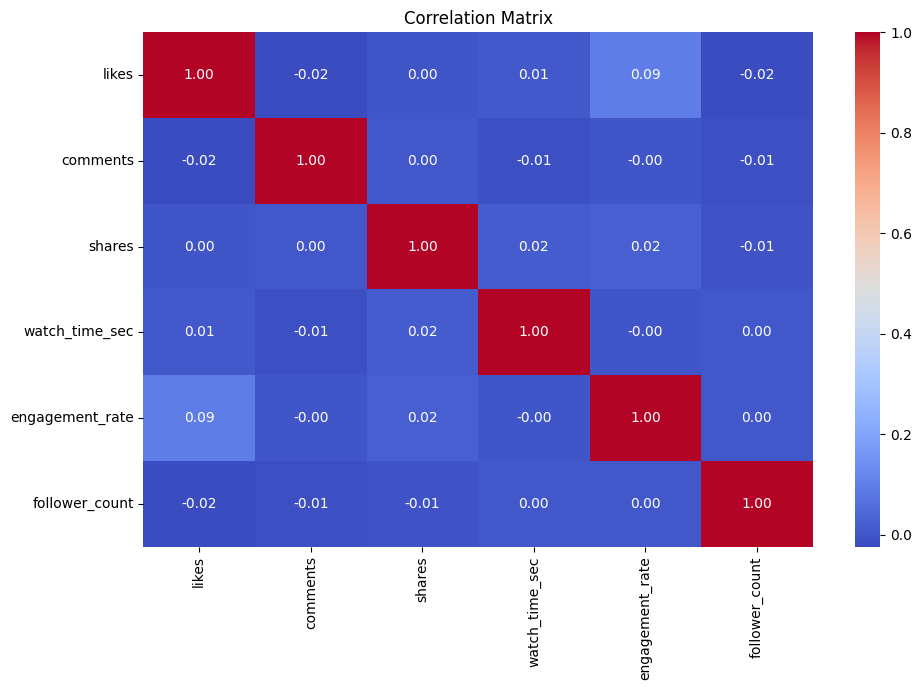

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [77]:
#Interactive Line Chart
import plotly.express as px

df["posted_at"] = pd.to_datetime(df["posted_at"])

daily_likes = df.groupby("posted_at", as_index=False)["likes"].mean()

fig = px.line(
    daily_likes,
    x="posted_at",
    y="likes",
    markers=True,
    title="Average Likes Over Time"
)

fig.show()

In [78]:
#Interactive Bar Chart
avg_likes = df.groupby("post_type", as_index=False)["likes"].mean()

fig = px.bar(
    avg_likes,
    x="post_type",
    y="likes",
    title="Average Likes by Post Type",
    text="likes"
)

fig.show()

In [79]:
#Interactive Scatter Chart
fig = px.scatter(
    df,
    x="follower_count",
    y="likes",
    color="sentiment",
    hover_data=["post_type", "post_category"],
    title="Followers vs Likes"
)

fig.show()

In [80]:
#Interactive Bubble Chart
fig = px.scatter(
    df,
    x="follower_count",
    y="likes",
    size="impression_count",
    color="post_type",
    hover_data=["post_category", "sentiment"],
    title="Followers vs Likes by Post Type"
)

fig.show()

In [82]:
#Which post types have highest engagement?
post_type_engagement = (
    df.groupby("post_type")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print(post_type_engagement)

post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64


In [83]:
#Best-performing content category
category_engagement = (
    df.groupby("post_category")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print(category_engagement)

post_category
food         1.358628
tech         1.160475
lifestyle    1.091019
music        0.888803
fitness      0.865628
education    0.844222
fashion      0.807109
travel       0.702223
Name: engagement_rate, dtype: float64


In [84]:
#Which countries have highest average engagement rate?
country_engagement = (
    df.groupby("country")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print(country_engagement)

country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


In [85]:
#How age affects engagement?
bins = [17, 24, 34, 44, 54, 64, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [86]:
age_engagement = (
    df.groupby("age_group", observed=True)["engagement_rate"]
      .mean()
)

print(age_engagement)

age_group
18-24    1.036141
25-34    0.810561
35-44    0.955580
45-54    1.205261
55-64    0.898814
Name: engagement_rate, dtype: float64


In [87]:
fig = px.bar(
    age_engagement.reset_index(),
    x="age_group",
    y="engagement_rate",
    title="Average Engagement Rate by Age Group",
    text="engagement_rate"
)

fig.show()

In [81]:
#Performance difference for verified accounts
verified_performance = df.groupby("is_verified").agg(
    avg_engagement_rate=("engagement_rate", "mean"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean")
)

print(verified_performance)

             avg_engagement_rate     avg_likes  avg_comments  avg_shares
is_verified                                                             
False                   0.954744  10025.819571   1549.095417  974.317025
True                    1.054250   9742.101449   1508.250518  998.888199


Content Performance:
The analysis shows that Video posting has the highest average engagement rate. Food and Tech are the best-performing content category.
Among countries, Brazil has the highest average engagement rate.

User Trends:
Engagement varies across age groups, with age group 45-54 showing the highest average engagement rate.
The analysis also shows a difference in average engagement performance between verified and non-verified accounts. Performance difference for verified accounts: Verified accounts have a higher average engagement rate and average shares compared with non-verified accounts. However, non-verified accounts have higher average likes and comments.

**Behavioral Insights**

In [105]:
#Best time/day for impressions:
df["posted_at"] = pd.to_datetime(df["posted_at"])

df["day_of_week"] = df["posted_at"].dt.day_name()

day_impressions = (
    df.groupby("day_of_week")["impression_count"]
      .mean()
      .reindex([
          "Monday", "Tuesday", "Wednesday",
          "Thursday", "Friday", "Saturday", "Sunday"
      ])
      .reset_index()
)

print(day_impressions)

  day_of_week  impression_count
0      Monday      50013.224928
1     Tuesday      51308.589849
2   Wednesday      49857.990000
3    Thursday      48119.289398
4      Friday      49430.537827
5    Saturday      50945.228095
6      Sunday      50345.670782


In [106]:
import plotly.express as px

fig = px.bar(
    day_impressions,
    x="day_of_week",
    y="impression_count",
    title="Average Impressions by Day of Week",
    labels={
        "day_of_week": "Day of Week",
        "impression_count": "Average Impressions"
    },
    text="impression_count"
)

fig.update_traces(
    texttemplate="%{text:.0f}",
    textposition="outside"
)

fig.show()

In [92]:
#Device type impact on watch time
device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
      .mean()
      .sort_values(ascending=False)
)

print(device_watch_time)

device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64


In [93]:
fig = px.bar(
    device_watch_time.reset_index(),
    x="device_type",
    y="watch_time_sec",
    title="Average Watch Time by Device Type",
    text="watch_time_sec",
    labels={
        "device_type": "Device Type",
        "watch_time_sec": "Average Watch Time (seconds)"
    }
)

fig.show()

Best time/day for impressions: Since the dataset contains posting dates but not the exact time of posting, hourly analysis is not possible. Based on the available data, Tuesday has the highest average impressions, indicating that posts published on Tuesday received the highest average impressions.

• Device type impact on watch time: mobile recorded the highest average watch time, while desktop recorded the lowest average watch time.

**Sentiment Analysis**

In [107]:
#Which sentiment performs best?
sentiment_performance = (
    df.groupby("sentiment")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print(sentiment_performance)

sentiment
negative    1.038486
neutral     0.991170
positive    0.954800
unknown     0.367493
Name: engagement_rate, dtype: float64


In [108]:
import plotly.express as px

fig = px.bar(
    sentiment_performance.reset_index(),
    x="sentiment",
    y="engagement_rate",
    title="Average Engagement Rate by Sentiment",
    labels={
        "sentiment": "Sentiment",
        "engagement_rate": "Average Engagement Rate"
    },
    text="engagement_rate"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.show()

In [109]:
#Behavior of negative/neutral sentiment posts
sentiment_behavior = (
    df[df["sentiment"].isin(["negative", "neutral"])]
    .groupby("sentiment")
    [["likes", "comments", "shares", "impression_count", "engagement_rate"]]
    .mean()
)

print(sentiment_behavior)

                  likes     comments      shares  impression_count  \
sentiment                                                            
negative   10094.987500  1552.019792  985.457292      50191.960417   
neutral     9818.899804  1566.987557  973.670596      49515.971185   

           engagement_rate  
sentiment                   
negative          1.038486  
neutral           0.991170  


In [110]:
fig = px.bar(
    sentiment_behavior.reset_index(),
    x="sentiment",
    y="engagement_rate",
    title="Engagement Rate of Negative and Neutral Posts",
    labels={
        "sentiment": "Sentiment",
        "engagement_rate": "Average Engagement Rate"
    },
    text="engagement_rate"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.show()

In [111]:
print(sentiment_performance)

sentiment
negative    1.038486
neutral     0.991170
positive    0.954800
unknown     0.367493
Name: engagement_rate, dtype: float64


In [112]:
sentiment_behavior = (
    df[df["sentiment"].isin(["negative", "neutral"])]
    .groupby("sentiment")
    [["likes", "comments", "shares", "impression_count", "engagement_rate"]]
    .mean()
)

print(sentiment_behavior)

                  likes     comments      shares  impression_count  \
sentiment                                                            
negative   10094.987500  1552.019792  985.457292      50191.960417   
neutral     9818.899804  1566.987557  973.670596      49515.971185   

           engagement_rate  
sentiment                   
negative          1.038486  
neutral           0.991170  


Negative sentiment posts have the highest average engagement rate (1.04), followed by neutral posts (0.99) and positive posts (0.95). Unknown sentiment posts have the lowest average engagement rate (0.37).

Behavior of negative/neutral sentiment posts: Negative sentiment posts generated higher average likes, shares, impressions, and engagement rate compared with neutral posts. However, neutral posts received slightly more comments on average. Overall, negative posts showed higher engagement in this dataset.

**SUMMARY**
## Final Analysis Insights

### Content Performance

* **Video posts** have the highest average engagement rate.
* **Food and Tech** are the best-performing content categories.
* **Brazil** has the highest average engagement rate among the countries analyzed.

### User Trends

* Engagement varies across age groups, with the **45–54 age group** showing the highest average engagement rate.
* **Verified accounts** have a higher average engagement rate and shares than non-verified accounts.
* **Non-verified accounts** have slightly higher average likes and comments.

### Behavioral Insights

* The dataset contains posting dates but not exact posting times, so hourly analysis is not possible. **Tuesday** has the highest average impressions among the days analyzed.
* **Mobile users** have the highest average watch time, while **desktop users** have the lowest average watch time.

### Sentiment Analysis

* **Negative sentiment posts** have the highest average engagement rate (**1.04**), followed by neutral (**0.99**) and positive (**0.95**) posts.
* Negative posts have higher average **likes, shares, impressions, and engagement rate** than neutral posts.
* Neutral posts receive slightly more **comments** than negative posts.
* Overall, negative sentiment posts show higher engagement in this dataset.
